# MFCC의 추출 실습

1. 오디오 신호를 프레임별로 나누어 FFT를 적용해 Spectrum을 구한다.

2. Spectrum에 Mel Filter Bank를 적용해 Mel Spectrum을 구한다.

3. Mel Spectrum에 Cepstral 분석을 적용해 MFCC를 구한다.


In [2]:
# 오디오파일 읽기, 푸리에 변환, 스펙트로그램
!pip install LIBROSA
# 콘다 환경에서는 conda install -c conda-forge LIBROSA

In [4]:
from google.colab import files
uploaded = files.upload()

Saving file_example_WAV_1MG.wav to file_example_WAV_1MG.wav


In [10]:
import librosa

file_path = "/content/file_example_WAV_1MG.wav"

audio, sampling_rate = librosa.load(
    file_path,
    sr=None,
    mono=True,
    offset=0.0,
    duration=None
)

len(audio), sampling_rate

(268237, 8000)

In [ ]:
# (268237, 8000) 1초당 8000개 샘플링

In [11]:
duration_of_sound = len(audio)/sampling_rate
print(duration_of_sound, " seconds")

33.529625  seconds


In [14]:
import IPython.display as lpd
lpd.Audio(file_path)

### 오디오 시각화

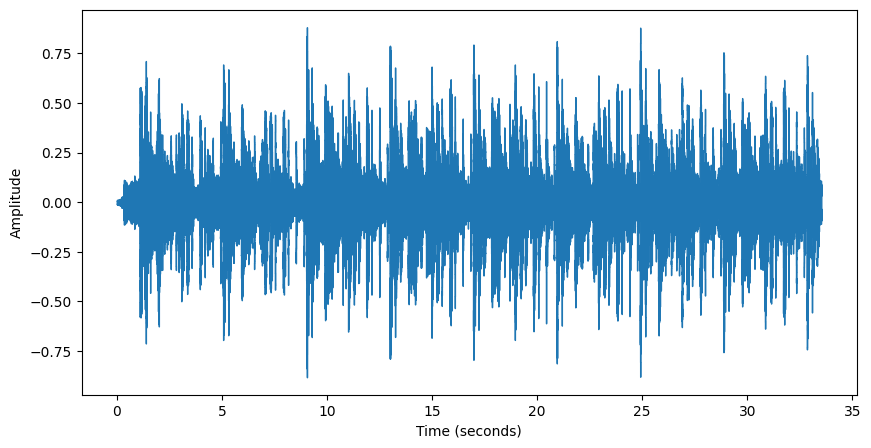

In [16]:
import matplotlib.pyplot as plt
import librosa.display

FIG_SIZE = (10, 5)

plt.figure(figsize=FIG_SIZE)
librosa.display.waveshow(audio, sr=sampling_rate)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

### 푸리에변환(FT)

Text(0, 0.5, '<----Amplitude---->')

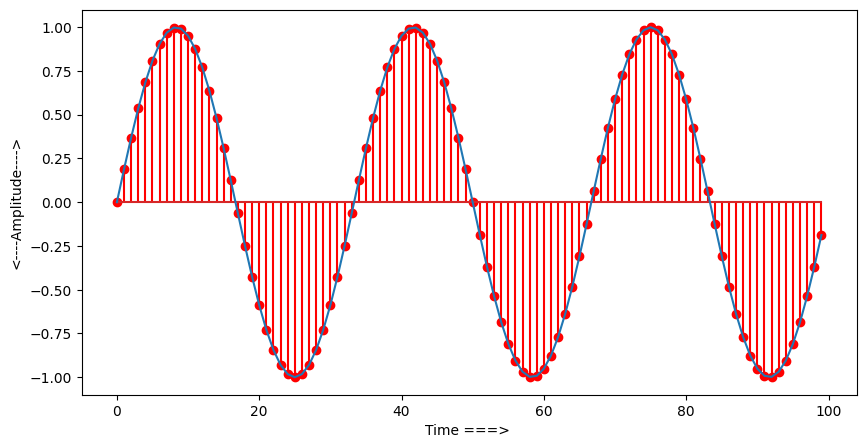

In [31]:
# 간단한 사인파 만들기
# 0부터 99까지의 샘플 위에 3주기짜리 사인파
import numpy as np
samples = 100
f = 3 # 주파수3짜리
x = np.arange(samples)
y1 = np.sin(2*np.pi*f*(x/samples))
plt.figure(figsize= FIG_SIZE)
plt.stem(x, y1, "r")
plt.plot(x,y1)
plt.xlabel("Time ===> ")
plt.ylabel("<----Amplitude---->")

In [32]:
from scipy.fft import fft
import numpy as np
import matplotlib.pyplot as plt

def fft_plot(audio, sampling_rate):
    n = len(audio)
    T = 1 / sampling_rate #샘플 하나 사이의 시간 간격

    yf = fft(audio) # yf: 주파수별 복소수 계수
    xf = np.linspace(0.0, sampling_rate / 2, n // 2)

    magnitude = 2.0 / n * np.abs(yf[:n // 2]) # 복소수 FFT 값의 magnitude계산, 양의 주파수만 선택

    plt.figure(figsize=(10, 5))
    plt.plot(xf, magnitude)
    plt.grid()
    plt.xlabel("Frequency --->")
    plt.ylabel("Magnitude")
    plt.show()

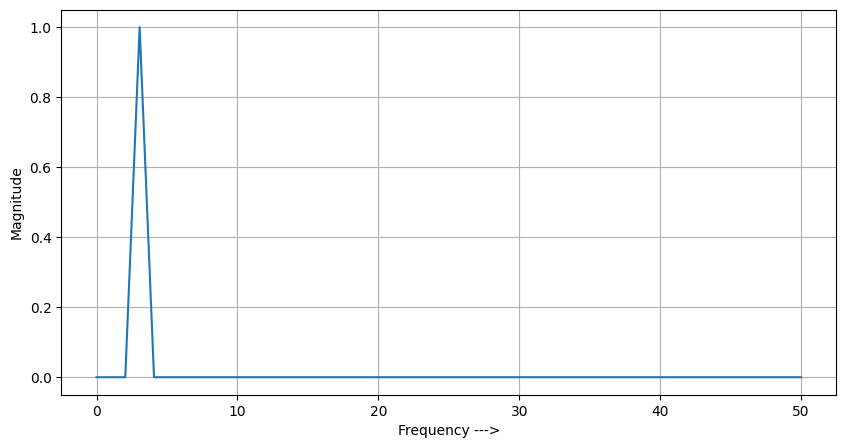

In [33]:
fft_plot(y1, 100)

Text(0, 0.5, '<----Amplitude---->')

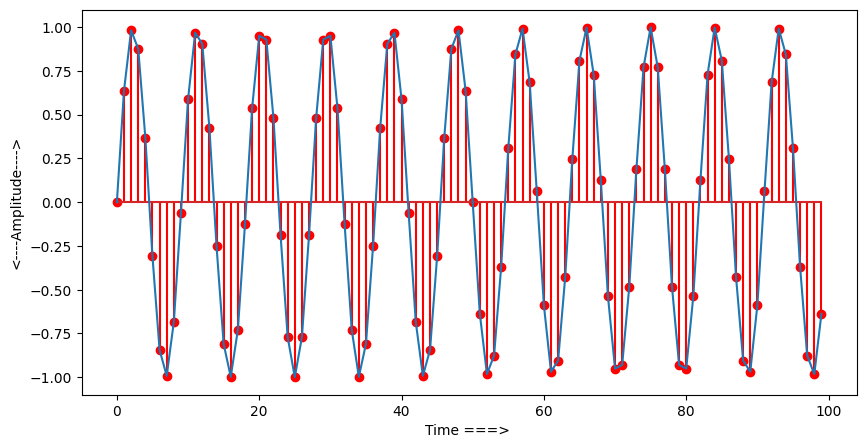

In [34]:

samples = 100
f = 11 # 주파수 11짜리
x = np.arange(samples)
y2 = np.sin(2*np.pi*f*(x/samples))
plt.figure(figsize= FIG_SIZE)
plt.stem(x, y2, "r")
plt.plot(x,y2)
plt.xlabel("Time ===> ")
plt.ylabel("<----Amplitude---->")

Text(0, 0.5, '<--Amplitude--->')

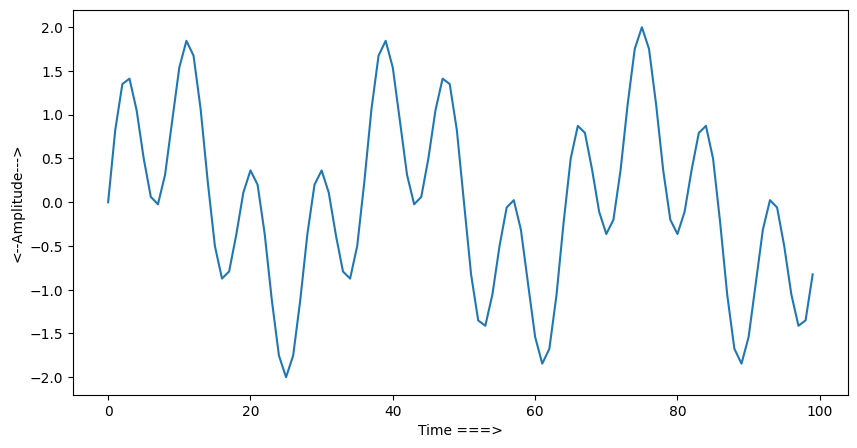

In [35]:
y3 = y1+y2
plt.figure(figsize=FIG_SIZE)
plt.plot(x,y3)
plt.xlabel("Time ===>")
plt.ylabel("<--Amplitude--->")

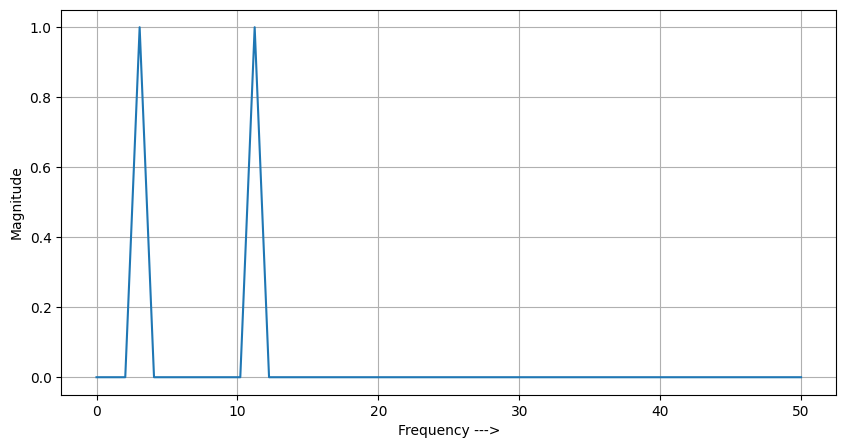

In [36]:
fft_plot(y3,100)

###실제 음성 푸리에변환

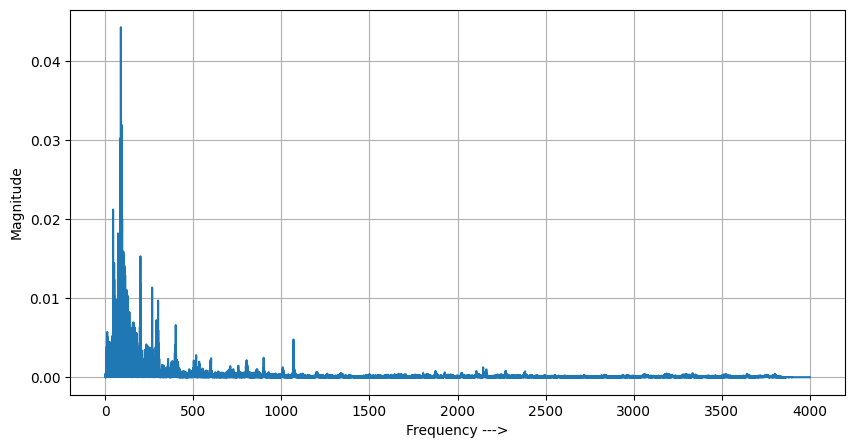

In [37]:
fft_plot(audio, sampling_rate)

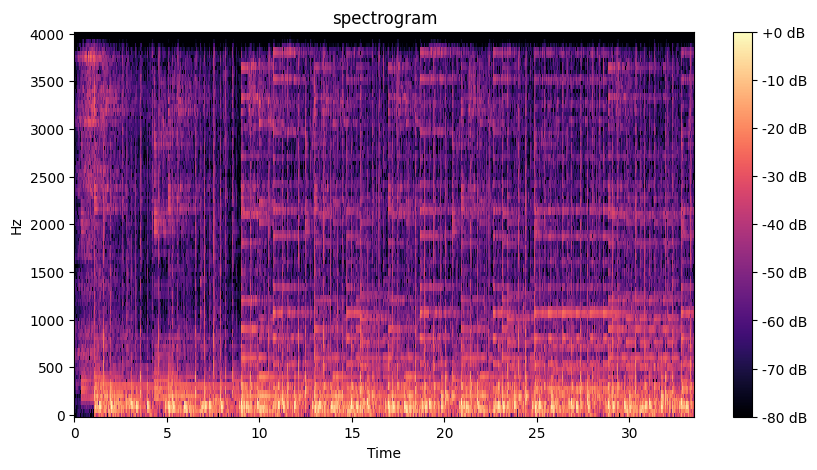

In [49]:
# display spectrogram
import matplotlib.pyplot as plt
import librosa.display

# librosa.display.specshow(spectrogram,sr=sampling_rate,
#     hop_length=stride_size, x_axis="time",y_axis="hz")

frame_size = 0.025
stride_size = 0.010

frame_length = int(frame_size * sampling_rate)
stride_size = int(stride_size * sampling_rate)

spectrogram = np.abs(librosa.stft(audio,n_fft=frame_length,
                                  hop_length=stride_size))

spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(10, 5))
plt.title("spectrogram")

librosa.display.specshow(spectrogram_db,sr=sampling_rate,hop_length=stride_size,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.show()


#### Framing

오디오를 20ms 길이의 작은 window들로 자르고, 각 window를 10ms 간격으로 이동하면서 겹치게 만드는 코드



In [50]:
samples = audio
sample_rate = sampling_rate
max_freq = sample_rate / 2

stride_ms = 10.0
window_ms = 20.0
eps = 1e-14

stride_size = int(0.001 * sample_rate * stride_ms)
window_size = int(0.001 * sample_rate * window_ms)

# Extract strided windows
truncate_size = (len(samples) - window_size) % stride_size
samples = samples[:len(samples) - truncate_size]

nshape = (window_size,(len(samples) - window_size) // stride_size + 1)

nstrides = (samples.strides[0],samples.strides[0] * stride_size)

windows = np.lib.stride_tricks.as_strided(samples, shape=nshape,strides=nstrides)

print("Sample Size :", len(samples))
print("Window Size :", window_size)
print("Stride Size :", stride_size)
print("Window Shape :", nshape)

Sample Size : 268160
Window Size : 160
Stride Size : 80
Window Shape : (160, 3351)


### Window

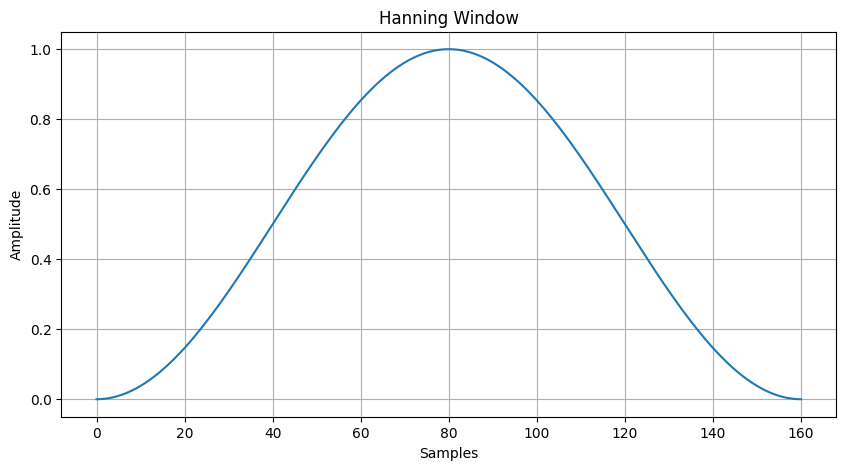

In [51]:
# Window weighting, squared Fast Fourier Transform (FFT), scaling

weighting = np.hanning(window_size)[:, None]

plt.figure(figsize=FIG_SIZE)
plt.plot(np.linspace(0, window_size, len(weighting)), weighting)
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Hanning Window")
plt.grid()
plt.show()

### FFT

In [61]:
# FFT
# 각 프레임에 window function을 곱한 뒤 FFT를 합니다.

# windows: 프레임 단위로 자른 음성 데이터
# weighting:  윈도우 함수
# windows * weighting: 각 프레임에 윈도우 적용
# np.fft.rfft(...): real-valued signal에 대한 FFT
# axis=0: 세로 방향, 즉 각 column/frame마다 FFT 수행

fft = np.fft.rfft(windows * weighting, axis=0)
fft = np.absolute(fft)
fft = fft ** 2 # power spectrum

scale = np.sum(weighting ** 2) * sample_rate #
fft[1:-1, :] *= (2.0 / scale)
fft[[0, -1], :] /= scale

# Prepare FFT frequency list
freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

# Compute spectrogram feature
ind = np.where(freqs <= max_freq)[0][-1] + 1
specgram = np.log(fft[:ind, :] + eps) # log-spectrum

print("Specgram Shape :", specgram.shape)

Specgram Shape : (81, 3351)


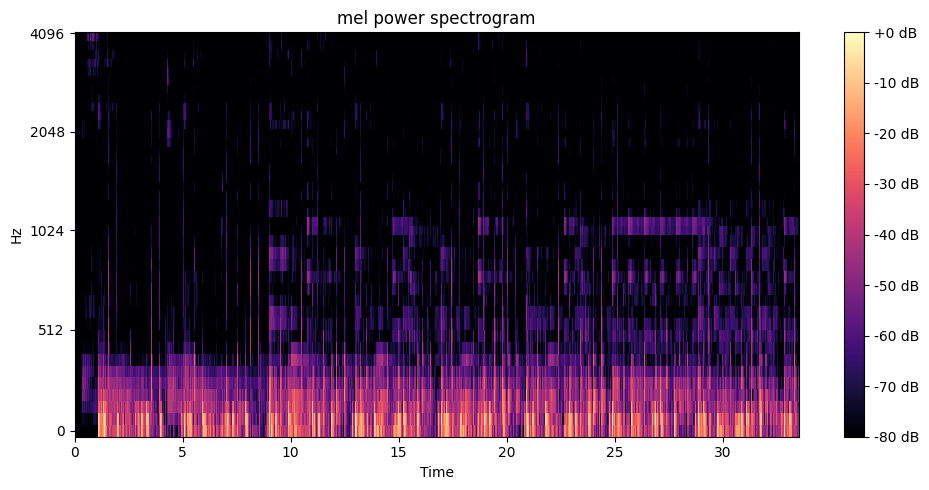

In [58]:
S = librosa.feature.melspectrogram(y=audio,sr=sampling_rate,n_fft=window_size,
    hop_length=stride_size,n_mels=40) # melspectrogram

log_S = librosa.amplitude_to_db(S, ref=np.max) # log melspectrogram

plt.figure(figsize=(10, 5))
librosa.display.specshow(log_S, sr=sampling_rate, hop_length=stride_size,
    x_axis='time',y_axis='mel')

plt.title('mel power spectrogram')
plt.colorbar(format='%+02.0f dB')
plt.tight_layout()
plt.show()

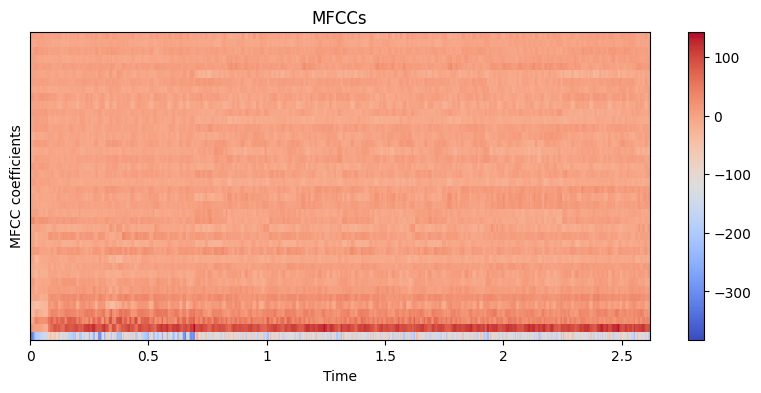

In [59]:
MFCCs = librosa.feature.mfcc(y=audio,sr=sample_rate, n_mfcc=40)

# display MFCCs
plt.figure(figsize=(10, 4))

librosa.display.specshow(MFCCs,sr=16000, hop_length=stride_size,x_axis='time')

plt.xlabel('Time')
plt.ylabel('MFCC coefficients')
plt.colorbar()
plt.title('MFCCs')

# show plots
plt.show()

In [60]:
MFCCs[:, 0] # 특징벡터

array([-3.8240561e+02,  3.5935883e+01, -1.3925688e+01, -3.6730141e+01,
       -3.3082016e+01, -7.4933767e+00,  5.8110552e+00,  1.3929591e+01,
        1.4834496e-01, -1.1143164e+01, -9.4830978e-01,  1.2429249e+01,
       -3.1848078e+00, -1.4582417e+00, -3.2074604e+00,  2.7913513e+01,
        4.3879824e+00, -8.1473122e+00, -4.6408868e+00, -5.0965028e+00,
        2.2763157e+00, -6.2363482e+00,  1.7304489e+01,  5.9824448e-02,
       -6.1249022e+00, -1.9186670e-01, -6.8573337e+00,  5.0049710e-01,
       -2.3329484e-01,  5.6091614e+00, -1.8899579e+00,  8.4607582e+00,
       -5.6797523e+00,  4.9114823e+00, -1.1733260e+00,  9.8874974e-01,
       -1.3199360e+00,  1.6460544e+00, -1.2013023e-01,  1.1350458e+00],
      dtype=float32)